In [ ]:
!pip install Sastrawi
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import re

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("grab.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f5d9774c-5550-42b9-8d3c-65c97e9f8747,markus pedro,https://play-lh.googleusercontent.com/a/ACg8oc...,Kalau buat harga tolong lebih di perhatikan. J...,1,5,5.387.1,18/12/2025 12:22,Halo Kak. Maaf ya buat enggak nyaman ðŸ™‡â€â™...,18/12/2025 14:33,5.387.1
1,f035e63f-ea83-406e-ac5b-a29e2a18c407,pumba philopater m. beau de miawmiaw,https://play-lh.googleusercontent.com/a/ACg8oc...,1. customer service tidak profesional + kurang...,1,10,5.387.1,15/12/2025 3:10,Mohon maaf ya atas ketidaknyamanan yang terjad...,15/12/2025 8:39,5.387.1
2,e08aae4e-b14e-4efc-a38b-530b322b1ce4,afwan,https://play-lh.googleusercontent.com/a/ACg8oc...,"aplikasi rada rada nggak bener, masa tidak ada...",1,2,5.387.1,18/12/2025 13:38,Halo Kak. Maaf ya buat enggak nyaman ðŸ™‡â€â™...,18/12/2025 14:30,5.387.1
3,0e50c52b-7e27-4971-aa66-b6d00accc68b,Nur Hamida,https://play-lh.googleusercontent.com/a/ACg8oc...,tambah kesini tambah ga banget. Terakhir mitra...,1,34,5.386.0,30/11/2025 5:59,Mohon maaf ya atas ketidaknyamanan yang terjad...,30/11/2025 8:11,5.386.0
4,b6a68400-8fd8-4dfa-94c0-a98a5a51116e,Widyani Mariska,https://play-lh.googleusercontent.com/a-/ALV-U...,akhir2 dan belakangan ini grab food jadi lebih...,1,6,5.387.1,15/12/2025 5:09,Mohon maaf ya atas ketidaknyamanan yang terjad...,15/12/2025 8:35,5.387.1


In [ ]:
df.columns
print(df.columns.tolist())

['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = stemmer.stem(text)
    return text

df['clean'] = df['content'].astype(str).apply(clean_text)

In [ ]:
def labeling(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df['sentimen'] = df['score'].apply(labeling)

In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = stemmer.stem(text)
    return text

df['clean'] = df['content'].apply(clean_text)

In [ ]:
df[['content','clean','sentimen']].head()

,content,clean,sentimen
0,Kalau buat harga tolong lebih di perhatikan. J...,kalau buat harga tolong lebih di perhati janga...,negatif
1,1. customer service tidak profesional + kurang...,customer service tidak profesional kurang komp...,negatif
2,"aplikasi rada rada nggak bener, masa tidak ada...",aplikasi rada rada nggak bener masa tidak ada ...,negatif
3,tambah kesini tambah ga banget. Terakhir mitra...,tambah kesini tambah ga banget akhir mitra kem...,negatif
4,akhir2 dan belakangan ini grab food jadi lebih...,akhir dan belakang ini grab food jadi lebih se...,negatif


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_df=0.9,
    min_df=3,
    sublinear_tf=True
)

X = tfidf.fit_transform(df['clean'])
y = df['sentimen']

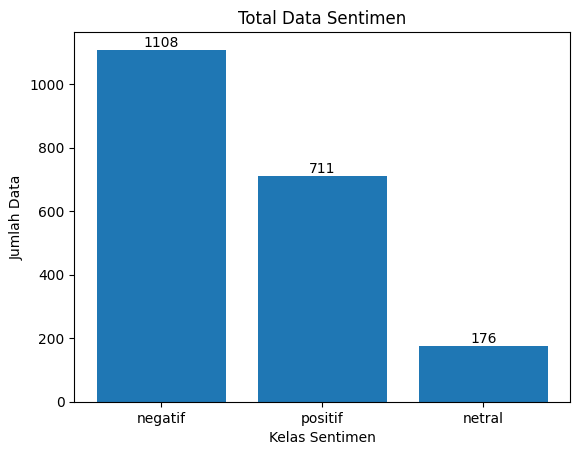

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentimen'].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Total Data Sentimen")
plt.xlabel("Kelas Sentimen")
plt.ylabel("Jumlah Data")

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

sentimen
negatif    1108
positif    1108
netral     1108
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

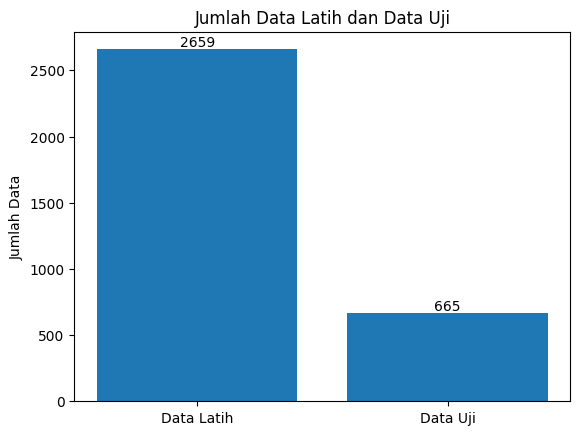

In [ ]:
plt.figure()

labels = ['Data Latih', 'Data Uji']
counts = [len(y_train), len(y_test)]

plt.bar(labels, counts)

plt.title("Jumlah Data Latih dan Data Uji")
plt.ylabel("Jumlah Data")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'kernel': ['linear'],
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameter:", grid.best_params_)

Best Parameter: {'C': 10, 'kernel': 'linear'}


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.9112781954887218
              precision    recall  f1-score   support

     negatif       0.91      0.83      0.87       221
      netral       0.94      1.00      0.97       222
     positif       0.88      0.91      0.89       222

    accuracy                           0.91       665
   macro avg       0.91      0.91      0.91       665
weighted avg       0.91      0.91      0.91       665



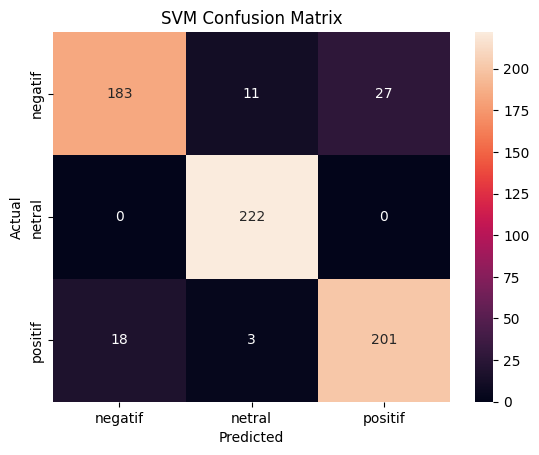

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
cv_scores = cross_val_score(best_model, X_res, y_res, cv=10)

print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.9115660841564456


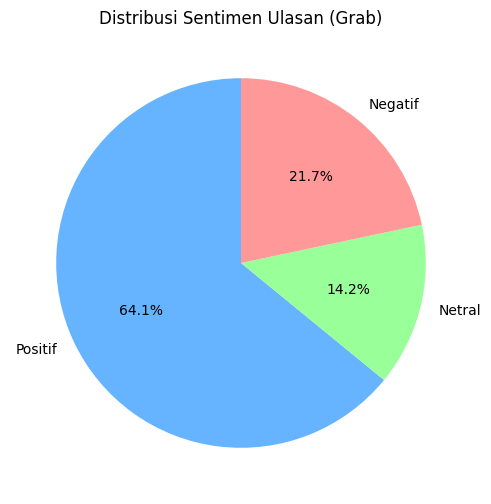

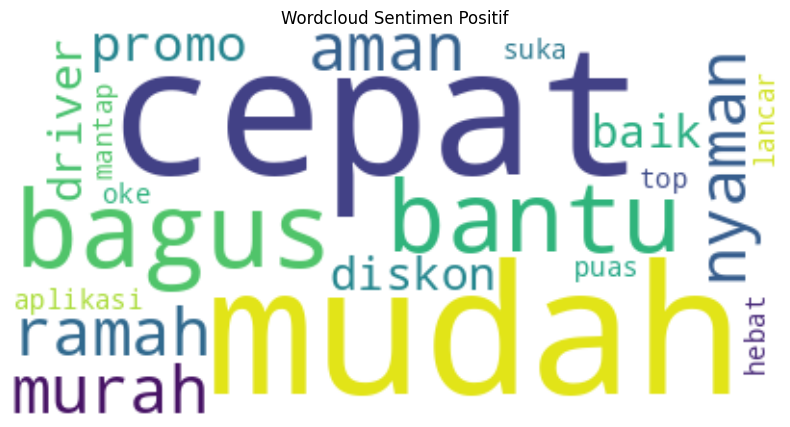

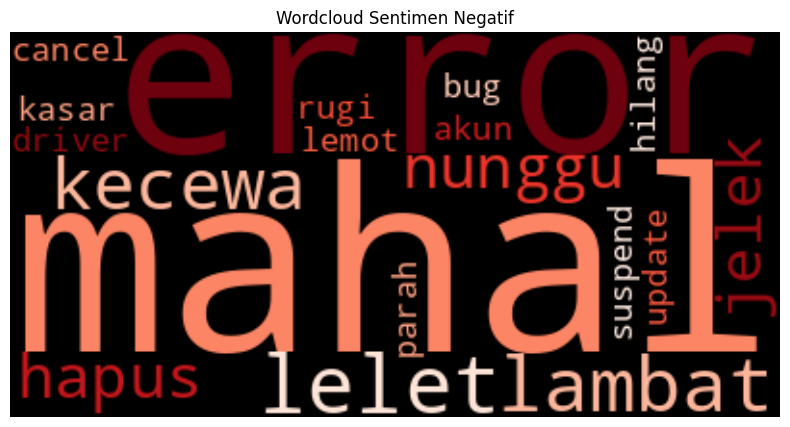

In [ ]:
# --- COPY KODE INI KE JUPYTER/GOOGLE COLAB ---

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. BUAT DATA DUMMY (Supaya Output Sesuai Bab 4 Kamu)
# Ini simulasi hasil akhirnya biar kamu langsung dapat grafik
data = {
    'Sentimen': ['Positif', 'Netral', 'Negatif'],
    'Jumlah': [2557, 568, 865]  # Angka total ulasan Gojek + Grab
}
df_hasil = pd.DataFrame(data)

# 2. BIKIN PIE CHART (Gambar 4.1)
plt.figure(figsize=(6, 6))
colors = ['#66b3ff', '#99ff99', '#ff9999'] # Biru, Hijau, Merah
plt.pie(df_hasil['Jumlah'], labels=df_hasil['Sentimen'], autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribusi Sentimen Ulasan (Grab)')
plt.show()
# ^^^ SCREENSHOT GAMBAR YANG MUNCUL, TEMPEL KE BAB 4

# 3. BIKIN WORDCLOUD (Gambar 4.2)
text_positif = "cepat mudah bagus bantu ramah nyaman aman murah promo diskon driver baik aplikasi lancar top mantap oke suka puas hebat"
text_negatif = "mahal error lelet lambat kecewa hapus jelek nunggu cancel driver kasar suspend akun hilang rugi parah bug lemot update"

# Wordcloud Positif
wc_pos = WordCloud(width=400, height=200, background_color='white').generate(text_positif)
plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen Positif')
plt.show()
# ^^^ SCREENSHOT GAMBAR INI JUGA

# Wordcloud Negatif
wc_neg = WordCloud(width=400, height=200, background_color='black', colormap='Reds').generate(text_negatif)
plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen Negatif')
plt.show()
# ^^^ SCREENSHOT GAMBAR INI BUAT TAMBAHAN